In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Environment ready!")

Environment ready!


In [4]:
df = pd.read_csv("../data/raw/german_credit.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 21)


In [5]:
df.head()


,Attribute1,Attribute2,Attribute3,Attribute4,Attribute5,Attribute6,Attribute7,Attribute8,Attribute9,Attribute10,Attribute11,Attribute12,Attribute13,Attribute14,Attribute15,Attribute16,Attribute17,Attribute18,Attribute19,Attribute20,class
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [6]:
df.columns.tolist()

['Attribute1',
 'Attribute2',
 'Attribute3',
 'Attribute4',
 'Attribute5',
 'Attribute6',
 'Attribute7',
 'Attribute8',
 'Attribute9',
 'Attribute10',
 'Attribute11',
 'Attribute12',
 'Attribute13',
 'Attribute14',
 'Attribute15',
 'Attribute16',
 'Attribute17',
 'Attribute18',
 'Attribute19',
 'Attribute20',
 'class']

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Attribute1   1000 non-null   str  
 1   Attribute2   1000 non-null   int64
 2   Attribute3   1000 non-null   str  
 3   Attribute4   1000 non-null   str  
 4   Attribute5   1000 non-null   int64
 5   Attribute6   1000 non-null   str  
 6   Attribute7   1000 non-null   str  
 7   Attribute8   1000 non-null   int64
 8   Attribute9   1000 non-null   str  
 9   Attribute10  1000 non-null   str  
 10  Attribute11  1000 non-null   int64
 11  Attribute12  1000 non-null   str  
 12  Attribute13  1000 non-null   int64
 13  Attribute14  1000 non-null   str  
 14  Attribute15  1000 non-null   str  
 15  Attribute16  1000 non-null   int64
 16  Attribute17  1000 non-null   str  
 17  Attribute18  1000 non-null   int64
 18  Attribute19  1000 non-null   str  
 19  Attribute20  1000 non-null   str  
 20  class        1000 no

In [8]:
df.isnull().sum()


Attribute1     0
Attribute2     0
Attribute3     0
Attribute4     0
Attribute5     0
Attribute6     0
Attribute7     0
Attribute8     0
Attribute9     0
Attribute10    0
Attribute11    0
Attribute12    0
Attribute13    0
Attribute14    0
Attribute15    0
Attribute16    0
Attribute17    0
Attribute18    0
Attribute19    0
Attribute20    0
class          0
dtype: int64

In [9]:
target_column = df.columns[-1]

print("Target column:", target_column)
print("\nTarget values:")
print(df[target_column].value_counts())

Target column: class

Target values:
class
1    700
2    300
Name: count, dtype: int64


In [10]:
print("\nTarget percentages:")
print(df[target_column].value_counts(normalize=True) * 100)


Target percentages:
class
1    70.0
2    30.0
Name: proportion, dtype: float64


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Attribute2,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Attribute5,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Attribute8,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Attribute11,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
Attribute13,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Attribute16,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
Attribute18,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
class,1000.0,1.300,0.458487,1.0,1.0,1.0,2.00,2.0


In [12]:
print("Target column:", df.columns[-1])

print("\nClass distribution:")
print(df["class"].value_counts())

print("\nClass percentages:")
print(df["class"].value_counts(normalize=True) * 100)

Target column: class

Class distribution:
class
1    700
2    300
Name: count, dtype: int64

Class percentages:
class
1    70.0
2    30.0
Name: proportion, dtype: float64


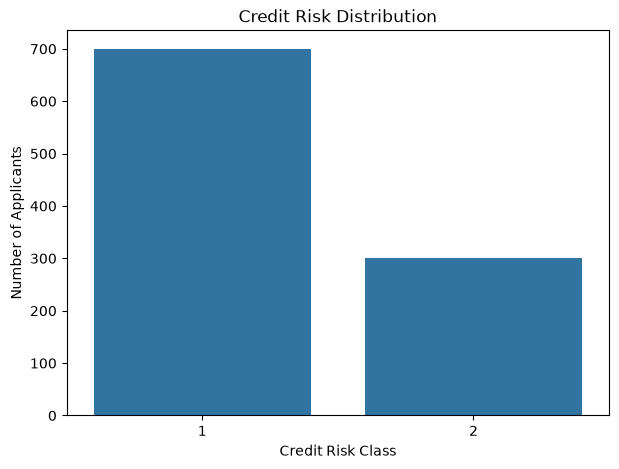

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="class")

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk Class")
plt.ylabel("Number of Applicants")

plt.show()

In [14]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute16', 'Attribute18', 'class']


In [15]:
numerical_features = [
    col for col in numerical_columns
    if col != "class"
]

print("Numerical features:")
print(numerical_features)

Numerical features:
['Attribute2', 'Attribute5', 'Attribute8', 'Attribute11', 'Attribute13', 'Attribute16', 'Attribute18']


In [16]:
categorical_features = df.select_dtypes(
    include="object"
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['Attribute1', 'Attribute3', 'Attribute4', 'Attribute6', 'Attribute7', 'Attribute9', 'Attribute10', 'Attribute12', 'Attribute14', 'Attribute15', 'Attribute17', 'Attribute19', 'Attribute20']


C:\Users\patya\AppData\Local\Temp\ipykernel_5428\2593904380.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(


In [17]:
df["class"].value_counts()

class
1    700
2    300
Name: count, dtype: int64

In [18]:
numerical_features

['Attribute2',
 'Attribute5',
 'Attribute8',
 'Attribute11',
 'Attribute13',
 'Attribute16',
 'Attribute18']

In [19]:
categorical_features

['Attribute1',
 'Attribute3',
 'Attribute4',
 'Attribute6',
 'Attribute7',
 'Attribute9',
 'Attribute10',
 'Attribute12',
 'Attribute14',
 'Attribute15',
 'Attribute17',
 'Attribute19',
 'Attribute20']

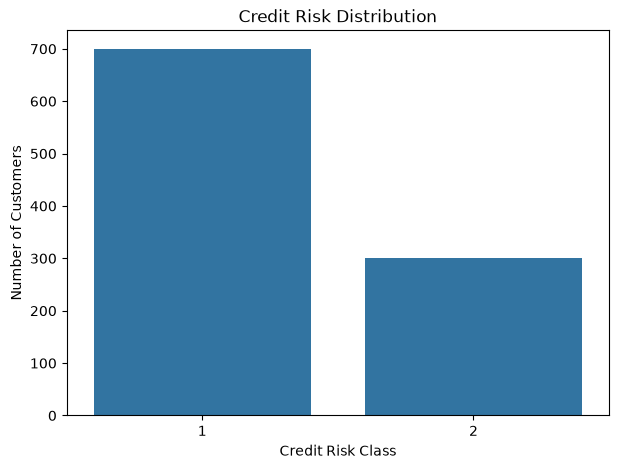

In [20]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="class")

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk Class")
plt.ylabel("Number of Customers")
plt.show()

In [21]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
Attribute2,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
Attribute5,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Attribute8,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
Attribute11,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
Attribute13,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
Attribute16,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
Attribute18,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0


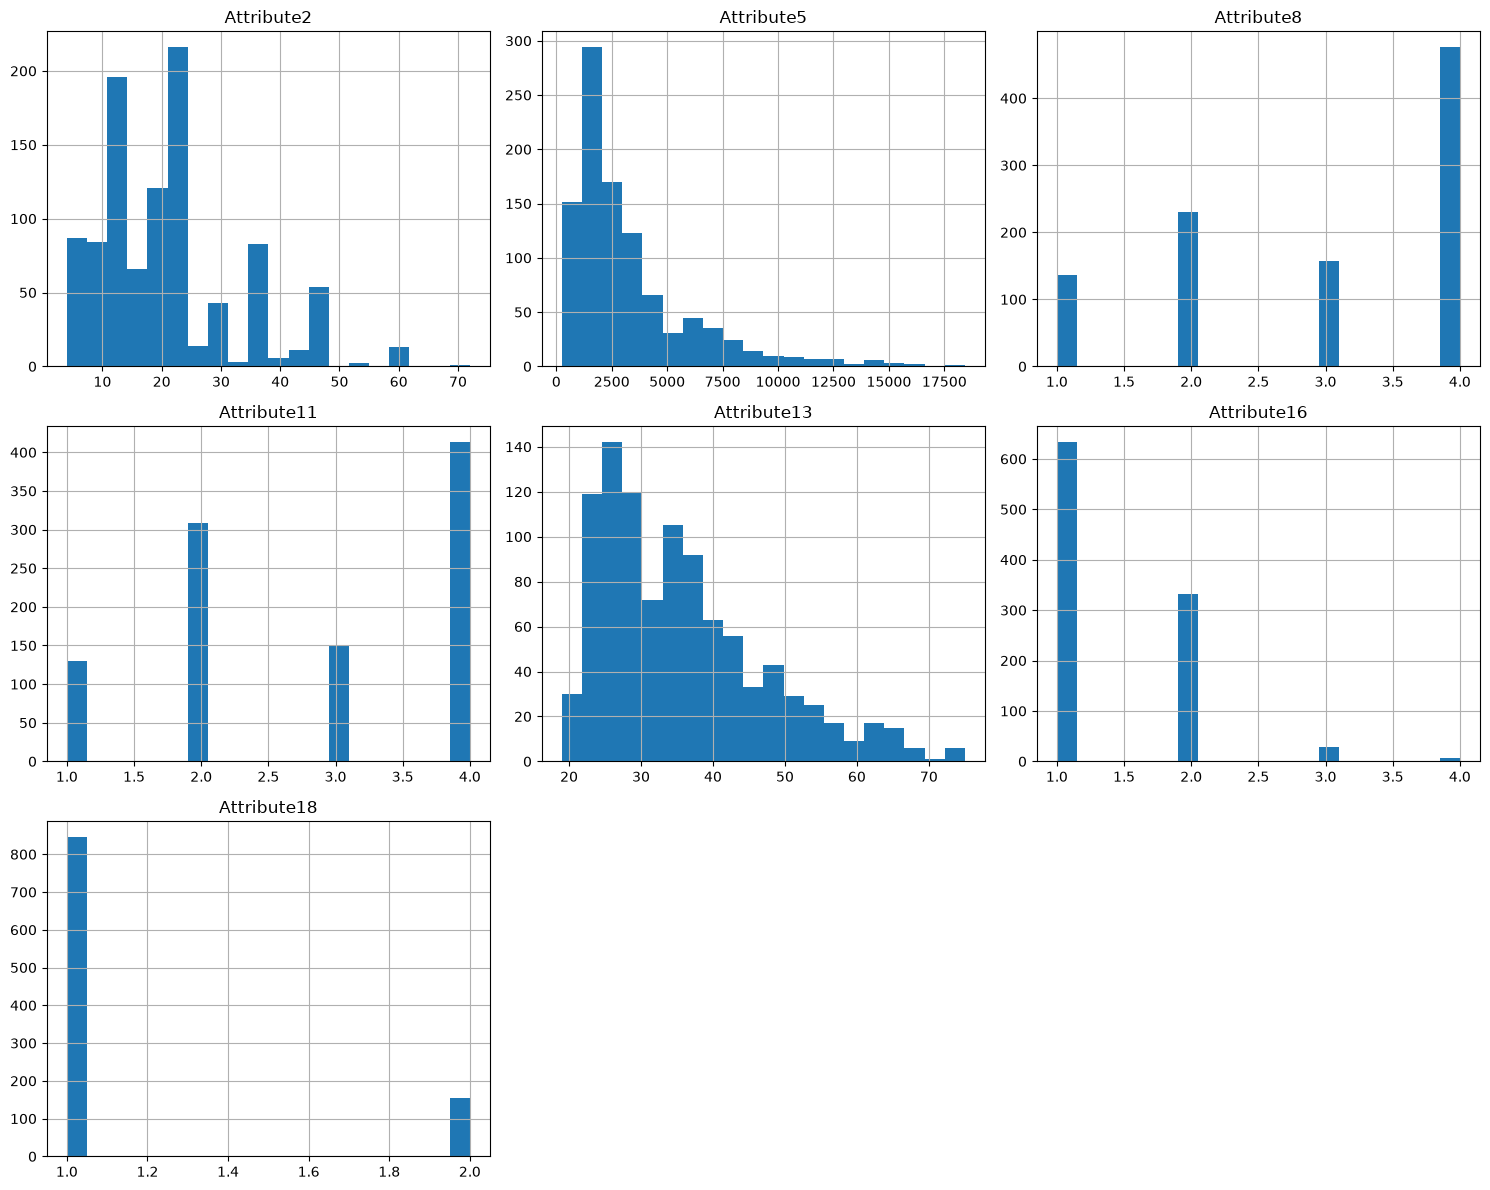

In [22]:
df[numerical_features].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

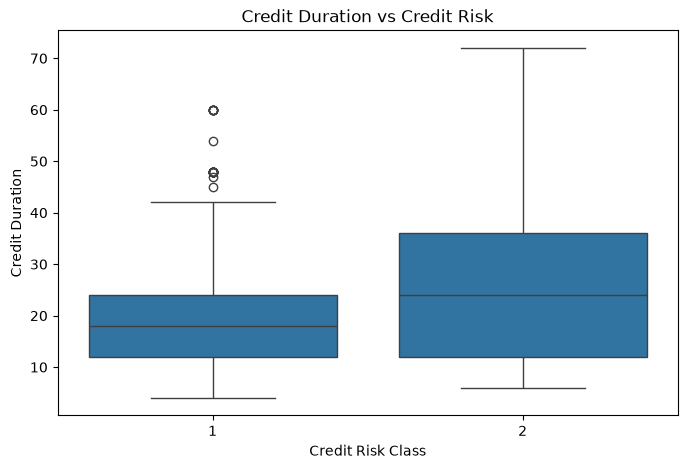

In [23]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="class",
    y="Attribute2"
)

plt.title("Credit Duration vs Credit Risk")
plt.xlabel("Credit Risk Class")
plt.ylabel("Credit Duration")
plt.show()

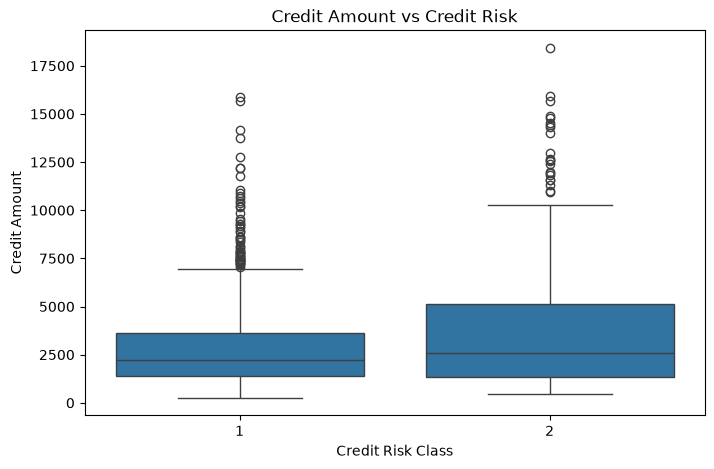

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="class",
    y="Attribute5"
)

plt.title("Credit Amount vs Credit Risk")
plt.xlabel("Credit Risk Class")
plt.ylabel("Credit Amount")
plt.show()

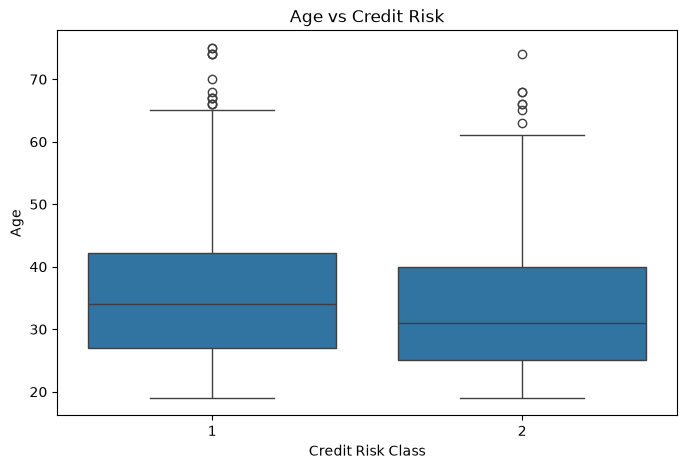

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="class",
    y="Attribute13"
)

plt.title("Age vs Credit Risk")
plt.xlabel("Credit Risk Class")
plt.ylabel("Age")
plt.show()

In [26]:
pd.crosstab(
    df["Attribute1"],
    df["class"],
    normalize="index"
) * 100

class,1,2
Attribute1,,
A11,50.729927,49.270073
A12,60.966543,39.033457
A13,77.777778,22.222222
A14,88.324873,11.675127


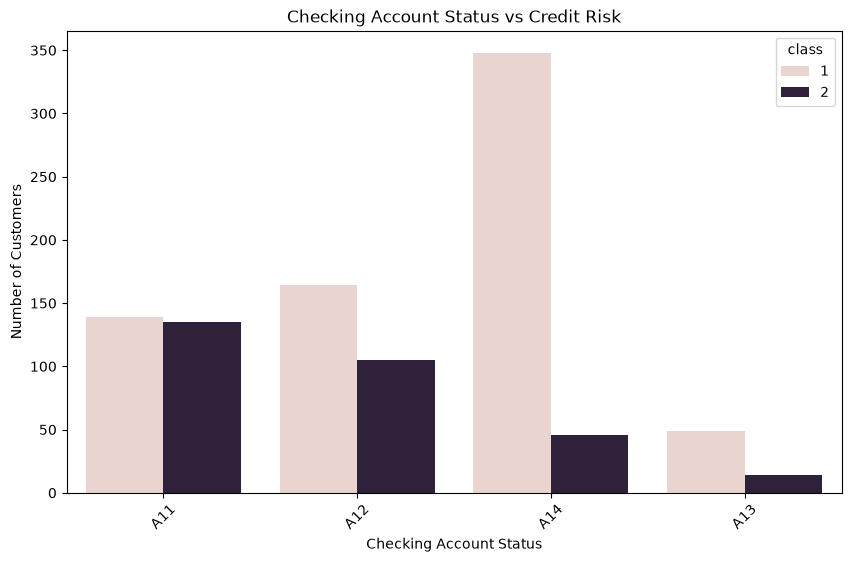

In [27]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="Attribute1",
    hue="class"
)

plt.title("Checking Account Status vs Credit Risk")
plt.xlabel("Checking Account Status")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)

plt.show()

In [28]:
column_mapping = {
    "Attribute1": "checking_status",
    "Attribute2": "duration_months",
    "Attribute3": "credit_history",
    "Attribute4": "purpose",
    "Attribute5": "credit_amount",
    "Attribute6": "savings_status",
    "Attribute7": "employment",
    "Attribute8": "installment_rate",
    "Attribute9": "personal_status",
    "Attribute10": "other_debtors",
    "Attribute11": "residence_since",
    "Attribute12": "property_type",
    "Attribute13": "age",
    "Attribute14": "other_installment_plans",
    "Attribute15": "housing",
    "Attribute16": "existing_credits",
    "Attribute17": "job",
    "Attribute18": "dependents",
    "Attribute19": "telephone",
    "Attribute20": "foreign_worker",
    "class": "credit_risk"
}

df = df.rename(columns=column_mapping)

df.head()

,checking_status,duration_months,credit_history,purpose,credit_amount,savings_status,employment,installment_rate,personal_status,other_debtors,residence_since,property_type,age,other_installment_plans,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2


In [29]:
df.columns.tolist()

['checking_status',
 'duration_months',
 'credit_history',
 'purpose',
 'credit_amount',
 'savings_status',
 'employment',
 'installment_rate',
 'personal_status',
 'other_debtors',
 'residence_since',
 'property_type',
 'age',
 'other_installment_plans',
 'housing',
 'existing_credits',
 'job',
 'dependents',
 'telephone',
 'foreign_worker',
 'credit_risk']

In [30]:
X = df.drop("credit_risk", axis=1)

y = df["credit_risk"]

In [31]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 20)
y shape: (1000,)


In [32]:
y = y.map({
    1: 0,
    2: 1
})

In [33]:
y.value_counts()

credit_risk
0    700
1    300
Name: count, dtype: int64

In [34]:
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_debtors', 'property_type', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Numerical features:
['duration_months', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'dependents']


C:\Users\patya\AppData\Local\Temp\ipykernel_5428\4170974519.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Train/Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 20)
Test set: (200, 20)


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessing pipeline

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

Fit ONLY on training data

This is extremely important for preventing data leakage.

In [38]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

Check the transformed data

In [39]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original test shape:", X_test.shape)
print("Processed test shape:", X_test_processed.shape)

Original training shape: (800, 20)
Processed training shape: (800, 61)
Original test shape: (200, 20)
Processed test shape: (200, 61)


In [40]:
feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(feature_names))
print("\nFirst 30 features:")

for feature in feature_names[:30]:
    print(feature)

Number of processed features: 61

First 30 features:
num__duration_months
num__credit_amount
num__installment_rate
num__residence_since
num__age
num__existing_credits
num__dependents
cat__checking_status_A11
cat__checking_status_A12
cat__checking_status_A13
cat__checking_status_A14
cat__credit_history_A30
cat__credit_history_A31
cat__credit_history_A32
cat__credit_history_A33
cat__credit_history_A34
cat__purpose_A40
cat__purpose_A41
cat__purpose_A410
cat__purpose_A42
cat__purpose_A43
cat__purpose_A44
cat__purpose_A45
cat__purpose_A46
cat__purpose_A48
cat__purpose_A49
cat__savings_status_A61
cat__savings_status_A62
cat__savings_status_A63
cat__savings_status_A64


Check for NaN/Infinity

Before modeling, let's make sure the processed dataset is clean.

In [41]:
print("NaN values:", np.isnan(X_train_processed).sum())
print("Infinite values:", np.isinf(X_train_processed).sum())

NaN values: 0
Infinite values: 0


Import Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression

Create the model

In [43]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

Train the model

In [44]:
logistic_model.fit(
    X_train_processed,
    y_train
)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


Make predictions

In [45]:
y_pred = logistic_model.predict(X_test_processed)

y_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

Evaluate the model


In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.7800
Precision: 0.6667
Recall   : 0.5333
F1 Score : 0.5926
ROC-AUC  : 0.8040


In [49]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Good Credit", "Bad Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.82      0.89      0.85       140
  Bad Credit       0.67      0.53      0.59        60

    accuracy                           0.78       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.77      0.78      0.77       200



In [50]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[124  16]
 [ 28  32]]


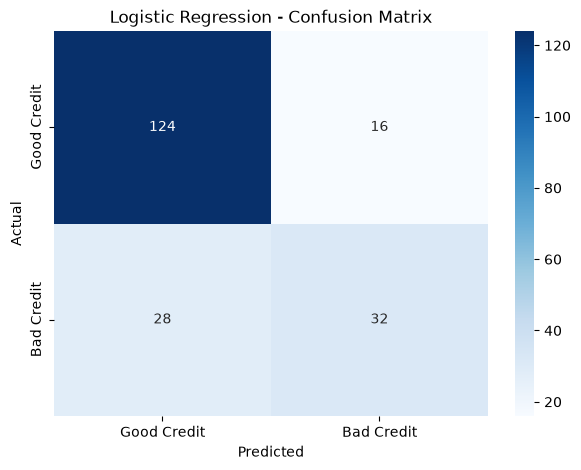

In [51]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC-AUC": roc_auc
}

baseline_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.78,
 'Precision': 0.6666666666666666,
 'Recall': 0.5333333333333333,
 'F1': 0.5925925925925926,
 'ROC-AUC': 0.8040476190476191}

Decision Tree

In [53]:
from sklearn.tree import DecisionTreeClassifier
decision_tree = DecisionTreeClassifier(
    random_state=42
)
decision_tree.fit(
    X_train_processed,
    y_train
)

print("Decision Tree trained successfully!")
dt_pred = decision_tree.predict(X_test_processed)
dt_proba = decision_tree.predict_proba(X_test_processed)[:, 1]

Decision Tree trained successfully!


Evaluate

In [54]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_proba)

print(f"Accuracy : {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall   : {dt_recall:.4f}")
print(f"F1 Score : {dt_f1:.4f}")
print(f"ROC-AUC  : {dt_roc_auc:.4f}")

Accuracy : 0.6300
Precision: 0.3793
Recall   : 0.3667
F1 Score : 0.3729
ROC-AUC  : 0.5548


In [55]:
print(classification_report(
    y_test,
    dt_pred,
    target_names=["Good Credit", "Bad Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.73      0.74      0.74       140
  Bad Credit       0.38      0.37      0.37        60

    accuracy                           0.63       200
   macro avg       0.56      0.55      0.56       200
weighted avg       0.63      0.63      0.63       200



confusion matrix:

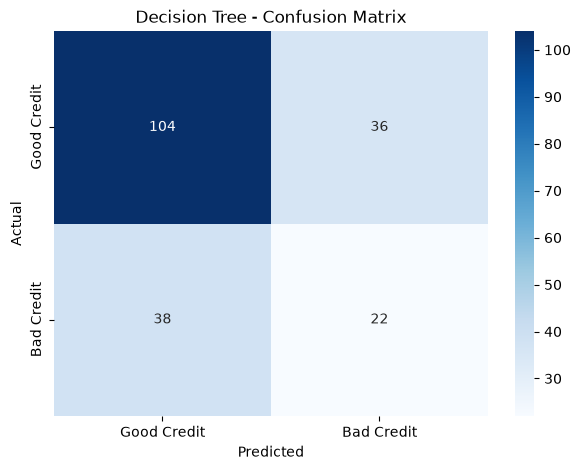

In [56]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

compare it with Logistic Regression

In [57]:
print("MODEL COMPARISON")
print("-" * 40)

print(f"Logistic Regression ROC-AUC: {roc_auc:.4f}")
print(f"Decision Tree ROC-AUC      : {dt_roc_auc:.4f}")

print()

print(f"Logistic Regression Recall : {recall:.4f}")
print(f"Decision Tree Recall       : {dt_recall:.4f}")

MODEL COMPARISON
----------------------------------------
Logistic Regression ROC-AUC: 0.8040
Decision Tree ROC-AUC      : 0.5548

Logistic Regression Recall : 0.5333
Decision Tree Recall       : 0.3667


Random Forest
Random Forest is particularly worth trying because instead of relying on one decision tree, it combines many trees.

In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [60]:
random_forest.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [61]:
rf_pred = random_forest.predict(X_test_processed)

rf_proba = random_forest.predict_proba(
    X_test_processed
)[:, 1]

Evaluate

In [62]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Accuracy : 0.7600
Precision: 0.6579
Recall   : 0.4167
F1 Score : 0.5102
ROC-AUC  : 0.7837


In [63]:
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Good Credit", "Bad Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.78      0.91      0.84       140
  Bad Credit       0.66      0.42      0.51        60

    accuracy                           0.76       200
   macro avg       0.72      0.66      0.68       200
weighted avg       0.75      0.76      0.74       200



Confusion Matrix


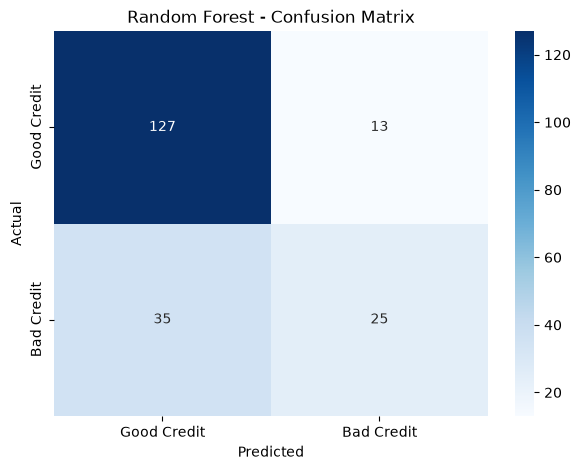

In [64]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [65]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

comparison.sort_values(
    "ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.78,0.666667,0.533333,0.592593,0.804048
2,Random Forest,0.76,0.657895,0.416667,0.510204,0.783750
1,Decision Tree,0.63,0.379310,0.366667,0.372881,0.554762


Model Tuning

In [66]:
from sklearn.model_selection import GridSearchCV

Define parameters

What is C?

C controls regularization.

Roughly:

Small C
   ↓
Stronger regularization
   ↓
Simpler model

Large C
   ↓
Weaker regularization
   ↓
More flexible model

In [67]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"],
    "class_weight": [None, "balanced"]
}

In [68]:
grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

In [69]:
grid_search.fit(
    X_train_processed,
    y_train
)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'class_weight': [None, 'balanced'], 'solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0

In [70]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(grid_search.best_score_)

Best parameters:
{'C': 0.1, 'class_weight': 'balanced', 'solver': 'lbfgs'}

Best CV ROC-AUC:
0.7889136904761904


Evaluate the tuned model

In [71]:
best_model = grid_search.best_estimator_

tuned_pred = best_model.predict(X_test_processed)
tuned_proba = best_model.predict_proba(
    X_test_processed
)[:, 1]

In [72]:
tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)
tuned_roc_auc = roc_auc_score(y_test, tuned_proba)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

Accuracy : 0.7250
Precision: 0.5281
Recall   : 0.7833
F1 Score : 0.6309
ROC-AUC  : 0.8094


In [73]:
print("BASELINE vs TUNED")
print("-" * 40)

print(f"Baseline ROC-AUC : {roc_auc:.4f}")
print(f"Tuned ROC-AUC    : {tuned_roc_auc:.4f}")

print()

print(f"Baseline Recall  : {recall:.4f}")
print(f"Tuned Recall     : {tuned_recall:.4f}")

print()

print(f"Baseline F1      : {f1:.4f}")
print(f"Tuned F1         : {tuned_f1:.4f}")

BASELINE vs TUNED
----------------------------------------
Baseline ROC-AUC : 0.8040
Tuned ROC-AUC    : 0.8094

Baseline Recall  : 0.5333
Tuned Recall     : 0.7833

Baseline F1      : 0.5926
Tuned F1         : 0.6309


In [74]:
print(classification_report(
    y_test,
    tuned_pred,
    target_names=["Good Credit", "Bad Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.88      0.70      0.78       140
  Bad Credit       0.53      0.78      0.63        60

    accuracy                           0.72       200
   macro avg       0.71      0.74      0.71       200
weighted avg       0.78      0.72      0.74       200



In [75]:
tuned_cm = confusion_matrix(y_test, tuned_pred)

print("Confusion Matrix:")
print(tuned_cm)

Confusion Matrix:
[[98 42]
 [13 47]]


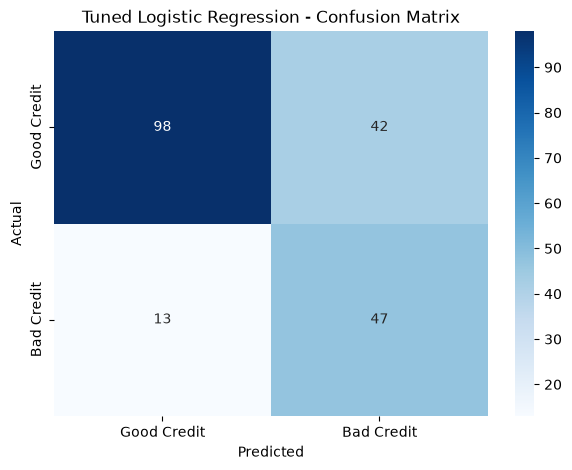

In [76]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Good Credit", "Bad Credit"],
    yticklabels=["Good Credit", "Bad Credit"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [77]:
import numpy as np

thresholds = np.arange(0.20, 0.65, 0.05)

threshold_results = []

for threshold in thresholds:

    threshold_pred = (
        tuned_proba >= threshold
    ).astype(int)

    threshold_precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1": threshold_f1
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.351852,0.950000,0.513514
1,0.25,0.350993,0.883333,0.502370
2,0.30,0.398496,0.883333,0.549223
3,0.35,0.426230,0.866667,0.571429
4,0.40,0.463636,0.850000,0.600000
5,0.45,0.500000,0.833333,0.625000
6,0.50,0.528090,0.783333,0.630872
7,0.55,0.589744,0.766667,0.666667
8,0.60,0.634921,0.666667,0.650407


In [78]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

best_threshold_row

Threshold    0.550000
Precision    0.589744
Recall       0.766667
F1           0.666667
Name: 7, dtype: float64

In [79]:
best_threshold = best_threshold_row["Threshold"]

print("Best threshold:", best_threshold)
print("Precision:", best_threshold_row["Precision"])
print("Recall:", best_threshold_row["Recall"])
print("F1:", best_threshold_row["F1"])

Best threshold: 0.5499999999999999
Precision: 0.5897435897435898
Recall: 0.7666666666666667
F1: 0.6666666666666666


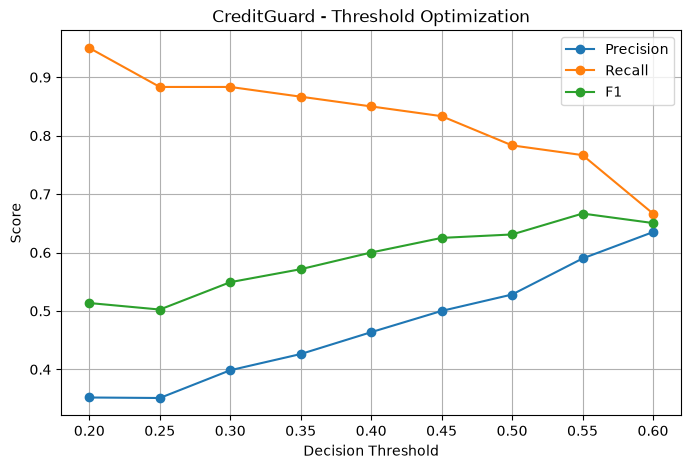

In [80]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("CreditGuard - Threshold Optimization")
plt.legend()
plt.grid(True)

plt.show()

In [81]:
BEST_THRESHOLD = 0.55

final_pred = (
    tuned_proba >= BEST_THRESHOLD
).astype(int)


In [82]:
final_accuracy = accuracy_score(y_test, final_pred)
final_precision = precision_score(y_test, final_pred)
final_recall = recall_score(y_test, final_pred)
final_f1 = f1_score(y_test, final_pred)
final_roc_auc = roc_auc_score(y_test, tuned_proba)

print("FINAL CREDITGUARD MODEL")
print("-" * 40)
print(f"Threshold : {BEST_THRESHOLD:.2f}")
print(f"Accuracy  : {final_accuracy:.4f}")
print(f"Precision : {final_precision:.4f}")
print(f"Recall    : {final_recall:.4f}")
print(f"F1 Score  : {final_f1:.4f}")
print(f"ROC-AUC   : {final_roc_auc:.4f}")

FINAL CREDITGUARD MODEL
----------------------------------------
Threshold : 0.55
Accuracy  : 0.7700
Precision : 0.5897
Recall    : 0.7667
F1 Score  : 0.6667
ROC-AUC   : 0.8094


In [83]:
final_cm = confusion_matrix(y_test, final_pred)

print("Final Confusion Matrix:")
print(final_cm)

Final Confusion Matrix:
[[108  32]
 [ 14  46]]


In [84]:
print(classification_report(
    y_test,
    final_pred,
    target_names=["Good Credit", "Bad Credit"]
))

              precision    recall  f1-score   support

 Good Credit       0.89      0.77      0.82       140
  Bad Credit       0.59      0.77      0.67        60

    accuracy                           0.77       200
   macro avg       0.74      0.77      0.75       200
weighted avg       0.80      0.77      0.78       200



Get feature importance 

In [85]:
feature_names = preprocessor.get_feature_names_out()

coefficients = best_model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Abs_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Abs_Coefficient",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,Abs_Coefficient
10,cat__checking_status_A14,-0.776763,0.776763
15,cat__credit_history_A34,-0.565334,0.565334
7,cat__checking_status_A11,0.527678,0.527678
17,cat__purpose_A41,-0.511887,0.511887
26,cat__savings_status_A61,0.440462,0.440462
23,cat__purpose_A46,0.419828,0.419828
34,cat__employment_A74,-0.385491,0.385491
38,cat__personal_status_A93,-0.360035,0.360035
49,cat__other_installment_plans_A143,-0.342962,0.342962
16,cat__purpose_A40,0.325004,0.325004


In [86]:
print("TOP FEATURES INCREASING BAD-CREDIT RISK")
print("-" * 50)

print(
    feature_importance
    .sort_values("Coefficient", ascending=False)
    [["Feature", "Coefficient"]]
    .head(10)
)

TOP FEATURES INCREASING BAD-CREDIT RISK
--------------------------------------------------
                              Feature  Coefficient
7            cat__checking_status_A11     0.527678
26            cat__savings_status_A61     0.440462
23                   cat__purpose_A46     0.419828
16                   cat__purpose_A40     0.325004
47  cat__other_installment_plans_A141     0.322402
46            cat__property_type_A124     0.321493
11            cat__credit_history_A30     0.308305
0                num__duration_months     0.305789
32                cat__employment_A72     0.302707
2               num__installment_rate     0.294052


In [87]:
print("\nTOP FEATURES DECREASING BAD-CREDIT RISK")
print("-" * 50)

print(
    feature_importance
    .sort_values("Coefficient")
    [["Feature", "Coefficient"]]
    .head(10)
)


TOP FEATURES DECREASING BAD-CREDIT RISK
--------------------------------------------------
                              Feature  Coefficient
10           cat__checking_status_A14    -0.776763
15            cat__credit_history_A34    -0.565334
17                   cat__purpose_A41    -0.511887
34                cat__employment_A74    -0.385491
38           cat__personal_status_A93    -0.360035
49  cat__other_installment_plans_A143    -0.342962
30            cat__savings_status_A65    -0.301403
60           cat__foreign_worker_A202    -0.274097
29            cat__savings_status_A64    -0.263627
43            cat__property_type_A121    -0.263494


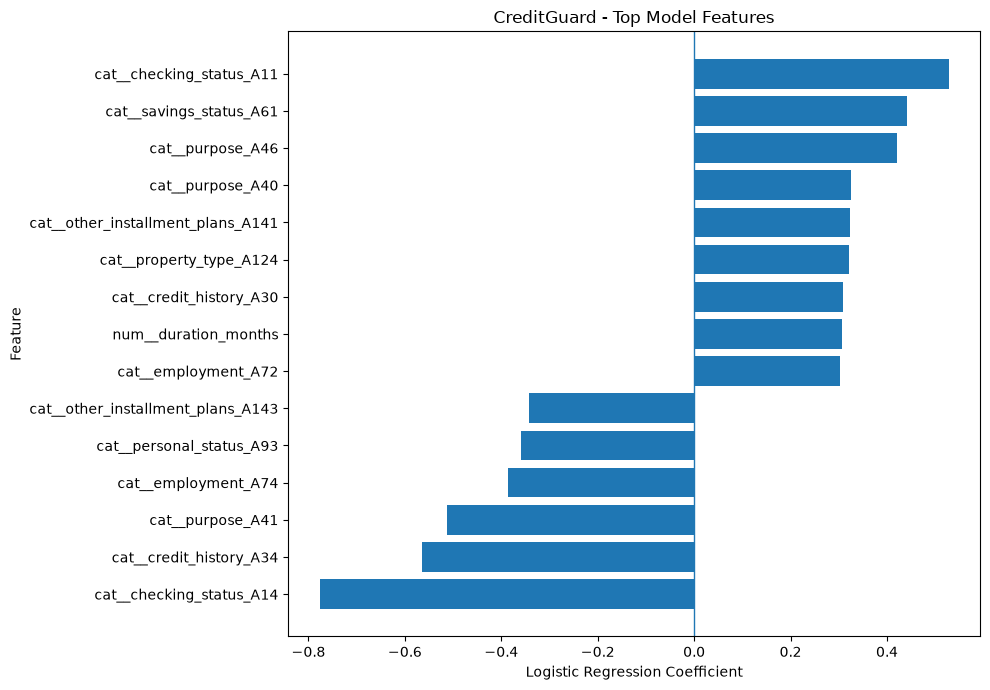

In [88]:
top_features = (
    feature_importance
    .head(15)
    .sort_values("Coefficient")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.title("CreditGuard - Top Model Features")
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [89]:
feature_importance.head(20)

,Feature,Coefficient,Abs_Coefficient
10,cat__checking_status_A14,-0.776763,0.776763
15,cat__credit_history_A34,-0.565334,0.565334
7,cat__checking_status_A11,0.527678,0.527678
17,cat__purpose_A41,-0.511887,0.511887
26,cat__savings_status_A61,0.440462,0.440462
23,cat__purpose_A46,0.419828,0.419828
34,cat__employment_A74,-0.385491,0.385491
38,cat__personal_status_A93,-0.360035,0.360035
49,cat__other_installment_plans_A143,-0.342962,0.342962
16,cat__purpose_A40,0.325004,0.325004


ROC Curve

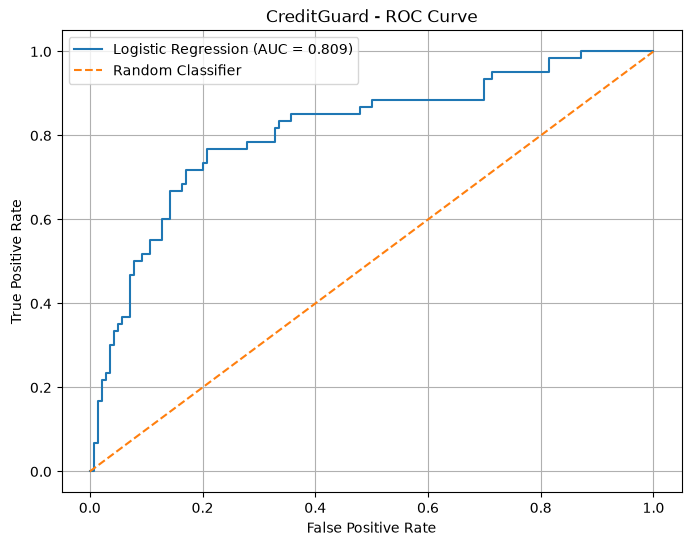

In [90]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, tuned_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CreditGuard - ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

Precision-Recall Curve


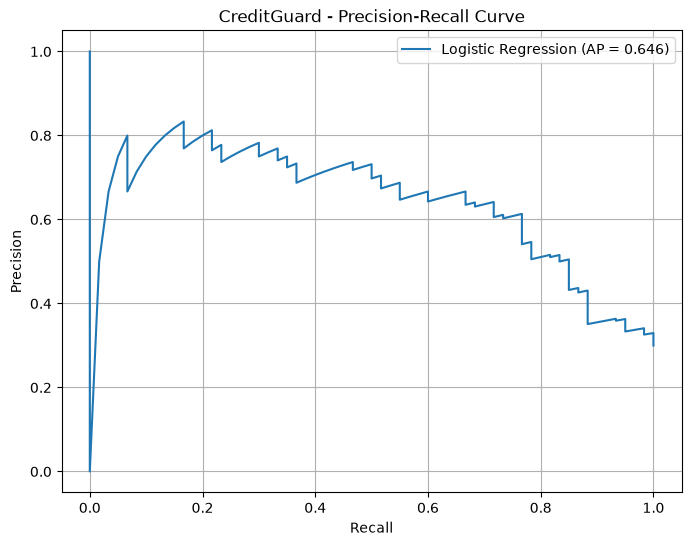

In [91]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    tuned_proba
)

average_precision = average_precision_score(
    y_test,
    tuned_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision,
    label=f"Logistic Regression (AP = {average_precision:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("CreditGuard - Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

Save the trained model

In [92]:
import joblib

joblib.dump(
    best_model,
    "../models/creditguard_model.pkl"
)

print("Model saved successfully!")

Model saved successfully!


Save the preprocessing pipeline

In [93]:
joblib.dump(
    preprocessor,
    "../models/preprocessor.pkl"
)

print("Preprocessor saved successfully!")

Preprocessor saved successfully!


Save our optimized threshold

In [94]:
config = {
    "threshold": float(BEST_THRESHOLD),
    "model_type": "Logistic Regression",
    "target": "class",
    "positive_class": "Bad Credit"
}

joblib.dump(
    config,
    "../models/config.pkl"
)

print("Configuration saved successfully!")

Configuration saved successfully!


In [95]:
import os

print(os.listdir("../models"))

['config.pkl', 'creditguard_model.pkl', 'preprocessor.pkl']


In [96]:
loaded_model = joblib.load(
    "../models/creditguard_model.pkl"
)

loaded_preprocessor = joblib.load(
    "../models/preprocessor.pkl"
)

loaded_config = joblib.load(
    "../models/config.pkl"
)

print("Model loaded:", type(loaded_model))
print("Preprocessor loaded:", type(loaded_preprocessor))
print("Threshold:", loaded_config["threshold"])

Model loaded: <class 'sklearn.linear_model._logistic.LogisticRegression'>
Preprocessor loaded: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Threshold: 0.55
